# Windowing the hip data into the ankle paper's input format

Builds the model-ready tensors for a replication of **Tourk et al., *Uncertainty-Aware Ankle
Exoskeleton Control*** ([arXiv:2508.21221](https://arxiv.org/abs/2508.21221)) on the Molinaro
hip dataset.

## Channel correspondence

The paper's 16 inputs are, per side: `accel [x,y,z]`, `gyro [x,y,z]`, joint angle, joint
velocity — bilateral. Every one has a direct hip counterpart:

| Ankle (Dephy ExoBoot) | Hip (Molinaro `exo.csv`) |
|---|---|
| shank/foot `accel [x,y,z]` | `thigh_accel_{x,y,z}_{l,r}` |
| shank/foot `gyro [x,y,z]` | `thigh_gyro_{x,y,z}_{l,r}` |
| ankle angle | `enc_angle_{l,r}` |
| ankle velocity (finite-differenced) | `enc_velo_{l,r}` (already differenced + 10 Hz causal Butterworth) |

Signs are left exactly as the dataset provides them — see §*Sign conventions* below.

## Three output sets

The four architectures don't want the same data, so this notebook writes three sets.

| Folder | For | Windows kept | Arrays |
|---|---|---|---|
| `data/processed/` | gait-phase ensemble | clean inputs **and** ≥1 leg labelled | `X`, `y`, `mask`, `meta` |
| `data/processed/AE_GAN/` | autoencoder, GAN, synthetic-target ensemble | clean inputs only | `X`, `meta` |
| `data/processed/ood/` | evaluating **all** models | clean inputs only, OOD modes | `X`, `meta` |

The autoencoder and GAN are unsupervised, so requiring a gait-phase label would discard
windows for a reason that doesn't apply to them. `AE_GAN/` therefore has **no labels and no
mask** — nothing to mask.

`ood/` is shared: OOD evaluation only needs `Ψ(x)`, never a label, so one copy serves every
model. Arrays are stored **unscaled** everywhere, with each family's scaler saved separately,
so the same OOD windows can be standardized by whichever scaler is appropriate.

## In-distribution vs out-of-distribution

The Molinaro dataset is all locomotion — it has no sitting, jumping, or lying down. We use
**held-out ambulation modes as pseudo-OOD**:

- **ID:** `LG`, `RA`, `RD` — treadmill level, ramp ascent, ramp descent
- **OOD:** `SA`, `SD` (overground stairs), `ST` (standing), `TR` (walk/stand transitions)

Training subjects contribute ID only. Validation and test subjects contribute **both**, which
mirrors the paper's design of testing on new participants performing a mix of familiar and
unfamiliar tasks.

Honest caveat for the writeup: stairs and standing are biomechanically far closer to
in-distribution walking than the paper's sitting/jumping/lying-down. Expect weaker separation
than their F1 of 90.3 — that is the expected outcome of a harder, more conservative OOD
definition, not a failure. `TRA`/`TRB` (overground transitions) exist only in Phase 2, whose
subjects aren't in this pool, so `TR` is the only transition mode available.

## Deliberate differences from the ankle paper

| | Ankle paper | Here | Why |
|---|---|---|---|
| Sample rate | 175 Hz | **200 Hz** | native rate of this dataset |
| Window | 175 samples (1 s) | **200 samples (1 s)** | preserves the 1-second receptive field |
| Stride | every 10th window | every 10th window | unchanged |
| Scaling | `StandardScaler` | `StandardScaler`, **fit on training subjects only** | unchanged |

The target is **`sin(2*pi*gait_phase)`**, not gait phase itself. Quoting the paper: *"To avoid the
discontinuity at heel strike when gait phase switches from 100 percent to 0 percent, we predict
the sine of gait phase."*

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 160)


def find_repo_root(marker: str = "data/molinaro-raw") -> Path:
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / marker).is_dir():
            return d
    raise FileNotFoundError(marker)


REPO = find_repo_root()
DATA_ROOT = REPO / "data" / "molinaro-raw"
CACHE = REPO / "data" / "cache"

OUT = REPO / "data" / "processed"          # gait-phase ensemble (labelled, masked)
OUT_AE = OUT / "AE_GAN"                    # unsupervised: no labels, no mask
OUT_OOD = OUT / "ood"                      # shared OOD evaluation set
for d in (OUT, OUT_AE, OUT_OOD):
    d.mkdir(parents=True, exist_ok=True)

inventory = pd.read_parquet(CACHE / "inventory.parquet")
print(f"inventory: {len(inventory):,} trials")
print(f"outputs -> {OUT.relative_to(REPO)}/ , {OUT_AE.relative_to(REPO)}/ , {OUT_OOD.relative_to(REPO)}/")

inventory: 5,364 trials
outputs -> data/processed/ , data/processed/AE_GAN/ , data/processed/ood/


In [2]:
# ---- channel definition, in the ankle paper's per-side order --------------------

def _side_block(side: str) -> list[str]:
    """accel xyz, gyro xyz, joint angle, joint velocity -- for one side."""
    return (
        [f"thigh_accel_{a}_{side}" for a in "xyz"]
        + [f"thigh_gyro_{a}_{side}" for a in "xyz"]
        + [f"enc_angle_{side}", f"enc_velo_{side}"]
    )


INPUT_16 = _side_block("l") + _side_block("r")
assert len(INPUT_16) == 16

# The ensemble's target: two outputs (left/right) through a tanh, range [-1, 1].
TARGET_GP = ["gp_hs_l", "gp_hs_r"]         # heel-strike-segmented phase, 0..1 in the CSV

SAMPLE_RATE_HZ = 200
WINDOW = 200   # 1.0 s
STRIDE = 10    # "every tenth window"

ID_MODES = ["LG", "RA", "RD"]              # treadmill locomotion
OOD_MODES = ["SA", "SD", "ST", "TR"]       # stairs, standing, transitions

for i, ch in enumerate(INPUT_16):
    print(f"  {i:2d}  {ch}")

   0  thigh_accel_x_l
   1  thigh_accel_y_l
   2  thigh_accel_z_l
   3  thigh_gyro_x_l
   4  thigh_gyro_y_l
   5  thigh_gyro_z_l
   6  enc_angle_l
   7  enc_velo_l
   8  thigh_accel_x_r
   9  thigh_accel_y_r
  10  thigh_accel_z_r
  11  thigh_gyro_x_r
  12  thigh_gyro_y_r
  13  thigh_gyro_z_r
  14  enc_angle_r
  15  enc_velo_r


## Sign conventions

Left exactly as the dataset provides them. Nothing is negated anywhere in this pipeline.

`thigh_gyro_y` is the sagittal axis and correlates **−0.90** with `enc_velo` (see
`01_load_molinaro.ipynb` §4), so gyro `y` is positive for hip *flexion* while the encoder is
positive for extension. That opposition is left in place, for three reasons:

1. Negating a channel is a linear reparameterisation that a first-layer convolution absorbs in
   its weights — it cannot change what the network is able to learn.
2. The two signals measure different quantities — absolute thigh angular velocity vs. relative
   hip joint velocity — which is exactly why the correlation is 0.90 rather than 1.0. Aligning
   their signs would imply an equivalence that doesn't hold.
3. What actually matters is *consistency*, and that is verified: the same sign on both legs and
   on all 34 subjects.

For downstream work that fuses the encoder and IMU (e.g. a Kalman filter), the sign and geometry
relationship belongs in the observation model, not baked into these arrays.

One genuine caveat: **`thigh_gyro_z_r` flips sign across subjects** (r from −0.78 to +0.63,
positive on 5 of 34), most likely IMU mounting rotation varying by session. That is real
per-subject inconsistency rather than a convention choice, and no global flip fixes it. It is
left raw here; if held-out-subject generalisation underperforms, it is the first thing to check.

## Subject-level splits

Train / validation / test are **disjoint by participant**, as in the paper (9/3/3 there,
12/4/4 here), so the uncertainty estimator is never validated on a body it trained on.

The pool is Phase 3–4 custom-exo trials. Phase 1–2 subjects are excluded: AB01–AB09 wore
different hardware (Samsung GEMS) with IMU data *transformed* into the custom exo's frames,
which would widen the in-distribution manifold for a reason that has nothing to do with human
movement.

In [3]:
POOL = inventory.query(
    "complete and phase in [3, 4] and exo_hardware == 'custom'"
).copy()

subjects = sorted(POOL["subject"].unique().tolist())
rng = np.random.default_rng(0)
shuffled = list(rng.permutation(subjects))

SPLITS = {
    "train": sorted(shuffled[:12]),
    "val": sorted(shuffled[12:16]),
    "test": sorted(shuffled[16:]),
}

ID_POOL = POOL[POOL["mode"].isin(ID_MODES)]
OOD_POOL = POOL[POOL["mode"].isin(OOD_MODES)]

rows = []
for name, subs in SPLITS.items():
    for kind, pool in [("ID", ID_POOL), ("OOD", OOD_POOL)]:
        if name == "train" and kind == "OOD":
            continue                          # training is in-distribution by definition
        d = pool[pool["subject"].isin(subs)]
        rows.append({"split": name, "kind": kind, "subjects": len(subs), "trials": len(d),
                     "hours": round(d["duration_s"].sum() / 3600, 2),
                     "modes": ",".join(sorted(d["mode"].unique()))})
display(pd.DataFrame(rows))

for name, subs in SPLITS.items():
    print(f"{name:5s} {subs}")
assert sum(len(v) for v in SPLITS.values()) == len(subjects)
assert not set(SPLITS["train"]) & set(SPLITS["val"]) & set(SPLITS["test"])

,split,kind,subjects,trials,hours,modes
0,train,ID,12,265,2.68,"LG,RA,RD"
1,val,ID,4,92,0.92,"LG,RA,RD"
2,val,OOD,4,210,0.38,"SA,SD,ST,TR"
3,test,ID,4,89,0.88,"LG,RA,RD"
4,test,OOD,4,214,0.38,"SA,SD,ST,TR"


train [np.str_('AB15'), np.str_('AB17'), np.str_('AB18'), np.str_('AB19'), np.str_('AB21'), np.str_('AB23'), np.str_('AB25'), np.str_('AB26'), np.str_('AB27'), np.str_('AB28'), np.str_('AB31'), np.str_('AB34')]
val   [np.str_('AB20'), np.str_('AB22'), np.str_('AB32'), np.str_('AB33')]
test  [np.str_('AB16'), np.str_('AB24'), np.str_('AB29'), np.str_('AB30')]


## Window extraction

A 200-sample window slides with stride 10. A window is kept if **no input channel contains a
NaN** anywhere in it. When `target_cols` is given, it must additionally have a label at its
**final** sample — the causal setup, where the model sees one second of history and predicts
the present instant.

Passing `target_cols=None` makes extraction unsupervised: no target file is read, no label
filter is applied, and no `y`/`mask` is produced. That is what `AE_GAN/` and `ood/` use.

Ground truth is **per leg** — inverse dynamics was only valid when that foot was on a force
plate, so a window can have a real left label and nothing on the right. In the supervised set
those windows are kept with `mask = 0` on the missing leg and `y = 0` as a placeholder.

In [4]:
def extract_windows(
    subject: str,
    trial: str,
    target_cols: list[str] | None = None,
    window: int = WINDOW,
    stride: int = STRIDE,
    require_both: bool = False,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return (X, y, mask, end_idx) for one trial.

    X    : (n_windows, 16, window) float32 -- channels-first, as conv1d expects
    y    : (n_windows, n_targets) float32  -- label at the final sample; empty if unsupervised
    mask : (n_windows, n_targets) float32  -- 1 where the label is real; empty if unsupervised
    end_idx : (n_windows,) int32           -- index of that final sample within the trial

    target_cols=None -> unsupervised: keep every window with clean inputs, read no labels.
    require_both=True -> supervised only; keep only fully-labelled windows.
    """
    d = DATA_ROOT / subject / trial
    X_full = pd.read_csv(d / "exo.csv", usecols=INPUT_16)[INPUT_16].to_numpy(np.float32)

    supervised = target_cols is not None
    n_t = len(target_cols) if supervised else 0
    empty = (np.empty((0, 16, window), np.float32), np.empty((0, n_t), np.float32),
             np.empty((0, n_t), np.float32), np.empty(0, np.int32))

    n = len(X_full)
    if n < window:
        return empty

    ends = np.arange(window - 1, n, stride, dtype=np.int32)

    # Reject any window containing a NaN input, via a prefix sum over bad rows.
    bad = np.isnan(X_full).any(axis=1)
    cum = np.concatenate([[0], np.cumsum(bad)])
    keep = (cum[ends + 1] - cum[ends + 1 - window]) == 0

    valid = None
    if supervised:
        tgt_file = "gp" if target_cols[0].startswith("gp_") else "moment"
        y_full = pd.read_csv(d / f"{tgt_file}.csv", usecols=target_cols)[target_cols].to_numpy(np.float32)
        valid = ~np.isnan(y_full[ends])                    # (n_windows, n_targets)
        keep = keep & (valid.all(axis=1) if require_both else valid.any(axis=1))

    ends_kept = ends[keep]
    if len(ends_kept) == 0:
        return empty

    starts = ends_kept - window + 1
    idx = starts[:, None] + np.arange(window)[None, :]     # (n_windows, window)
    X = np.ascontiguousarray(np.transpose(X_full[idx], (0, 2, 1)))

    if not supervised:
        return X, empty[1], empty[2], ends_kept

    y = np.nan_to_num(y_full[ends_kept], nan=0.0)          # masked entries must not be NaN
    mask = valid[keep].astype(np.float32)
    return X, y, mask, ends_kept


def to_sine_phase(y: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Gait phase 0..1 -> sin(2*pi*phase), in [-1, 1].

    The paper predicts the SINE of gait phase to avoid the discontinuity at heel strike, where
    a raw 0..1 sawtooth jumps by its full range. Masked-out entries stay at 0 rather than
    mapping to -1, so they can't be mistaken for a real label.
    """
    return np.where(mask > 0, np.sin(2.0 * np.pi * y), 0.0).astype(np.float32)


# Smoke test both modes on the same trial.
for _t in ID_POOL.itertuples():
    Xs, ys, ms, es = extract_windows(_t.subject, _t.trial, TARGET_GP)
    if len(es):
        break
Xu, _, _, eu = extract_windows(_t.subject, _t.trial, None)
print(f"{_t.subject}/{_t.trial}")
print(f"  supervised   : X{Xs.shape} y{ys.shape} mask{ms.shape}  "
      f"label coverage L={ms[:, 0].mean():.0%} R={ms[:, 1].mean():.0%}")
print(f"  unsupervised : X{Xu.shape}  (+{len(eu) - len(es)} windows kept that lack a label)")
print(f"  NaNs in X: {int(np.isnan(Xu).sum())}")

AB15/LG_C0p0_S0p75_UC_1
  supervised   : X(52, 16, 200) y(52, 2) mask(52, 2)  label coverage L=100% R=0%
  unsupervised : X(621, 16, 200)  (+569 windows kept that lack a label)
  NaNs in X: 0


## Building the split datasets

Windows are written straight into **memory-mapped `.npy`** files rather than accumulated in
RAM. Two passes — count, then fill — keep peak memory to a single trial.

In [5]:
def build_split(
    name: str,
    trials: pd.DataFrame,
    target_cols: list[str] | None = None,
    out_dir: Path | None = None,
    overwrite: bool = False,
) -> dict:
    """Write one split to disk. Supervised (target_cols given) also writes y and mask."""
    out_dir = out_dir or OUT
    out_dir.mkdir(parents=True, exist_ok=True)
    supervised = target_cols is not None
    tag = out_dir.name if out_dir != OUT else "ensemble"

    paths = {"X": out_dir / f"{name}_X.npy", "meta": out_dir / f"{name}_meta.parquet"}
    if supervised:
        paths["y"] = out_dir / f"{name}_y.npy"
        paths["mask"] = out_dir / f"{name}_mask.npy"

    if paths["X"].exists() and not overwrite:
        X = np.load(paths["X"], mmap_mode="r")
        print(f"[{tag}/{name}] already built: X{X.shape} -- pass overwrite=True to rebuild")
        return paths

    n_t = len(target_cols) if supervised else 0

    counts, kept = [], []
    for r in trials.itertuples():
        *_, ends = extract_windows(r.subject, r.trial, target_cols)
        if len(ends):
            counts.append(len(ends)); kept.append(r)
    total = int(sum(counts))
    print(f"[{tag}/{name}] {len(kept)}/{len(trials)} trials -> {total:,} windows "
          f"({total * 16 * WINDOW * 4 / 1e9:.2f} GB)")

    mm = {"X": np.lib.format.open_memmap(paths["X"], mode="w+", dtype=np.float32,
                                         shape=(total, 16, WINDOW))}
    if supervised:
        mm["y"] = np.lib.format.open_memmap(paths["y"], mode="w+", dtype=np.float32,
                                            shape=(total, n_t))
        mm["mask"] = np.lib.format.open_memmap(paths["mask"], mode="w+", dtype=np.float32,
                                               shape=(total, n_t))

    rows, off = [], 0
    for r, n in zip(kept, counts):
        X, y, mask, ends = extract_windows(r.subject, r.trial, target_cols)
        mm["X"][off:off + n] = X
        if supervised:
            mm["y"][off:off + n] = to_sine_phase(y, mask) if target_cols[0].startswith("gp_") else y
            mm["mask"][off:off + n] = mask
        rows.append(pd.DataFrame({
            "subject": r.subject, "trial": r.trial, "mode": r.mode,
            "condition": r.condition, "speed": r.speed, "controller": r.controller,
            "end_idx": ends, "row": np.arange(off, off + n, dtype=np.int64),
        }))
        off += n
    for a in mm.values():
        a.flush()
    del mm

    pd.concat(rows, ignore_index=True).to_parquet(paths["meta"], index=False)
    print(f"[{tag}/{name}] wrote {', '.join(p.name for p in paths.values())}")
    return paths


paths = {"ensemble": {}, "AE_GAN": {}, "ood": {}}

print("=== gait-phase ensemble: ID modes, labelled + masked ===")
for name, subs in SPLITS.items():
    paths["ensemble"][name] = build_split(
        name, ID_POOL[ID_POOL["subject"].isin(subs)], TARGET_GP, OUT)

print("\n=== AE / GAN: ID modes, unsupervised (no labels, no mask) ===")
for name, subs in SPLITS.items():
    paths["AE_GAN"][name] = build_split(
        name, ID_POOL[ID_POOL["subject"].isin(subs)], None, OUT_AE)

print("\n=== OOD evaluation set: held-out modes, val/test subjects only ===")
for name in ("val", "test"):
    paths["ood"][name] = build_split(
        name, OOD_POOL[OOD_POOL["subject"].isin(SPLITS[name])], None, OUT_OOD)

=== gait-phase ensemble: ID modes, labelled + masked ===
[ensemble/train] already built: X(168956, 16, 200) -- pass overwrite=True to rebuild
[ensemble/val] already built: X(59952, 16, 200) -- pass overwrite=True to rebuild
[ensemble/test] already built: X(58045, 16, 200) -- pass overwrite=True to rebuild

=== AE / GAN: ID modes, unsupervised (no labels, no mask) ===
[AE_GAN/train] already built: X(187993, 16, 200) -- pass overwrite=True to rebuild
[AE_GAN/val] already built: X(64350, 16, 200) -- pass overwrite=True to rebuild
[AE_GAN/test] already built: X(61956, 16, 200) -- pass overwrite=True to rebuild

=== OOD evaluation set: held-out modes, val/test subjects only ===
[ood/val] already built: X(23344, 16, 200) -- pass overwrite=True to rebuild
[ood/test] already built: X(23043, 16, 200) -- pass overwrite=True to rebuild


## Standardization

`StandardScaler` fit on the **training split only**, per channel, pooling across all windows
and timesteps. Fitting on val/test would leak information about the held-out participants into
the uncertainty threshold.

Each family gets its own scaler, fit on its own training set — they differ slightly because
`AE_GAN/` keeps windows the labelled set drops. Arrays are stored **unscaled**, so the shared
`ood/` windows can be standardized by whichever scaler is doing the evaluating.

In [6]:
def fit_scaler(x_path: Path, max_windows: int = 60_000, seed: int = 0) -> dict:
    """Per-channel mean/std over a random subsample of training windows."""
    X = np.load(x_path, mmap_mode="r")
    rng = np.random.default_rng(seed)
    n = min(max_windows, len(X))
    idx = np.sort(rng.choice(len(X), size=n, replace=False))
    sub = np.asarray(X[idx], dtype=np.float64)
    mean, std = sub.mean(axis=(0, 2)), sub.std(axis=(0, 2))
    std[std < 1e-8] = 1.0
    return {"mean": mean.astype(np.float32), "std": std.astype(np.float32),
            "n_windows_used": int(n)}


def apply_scaler(X: np.ndarray, scaler: dict) -> np.ndarray:
    """Standardize a (n, 16, T) batch."""
    return (X - scaler["mean"][None, :, None]) / scaler["std"][None, :, None]


scalers = {}
for fam, out_dir in [("ensemble", OUT), ("AE_GAN", OUT_AE)]:
    sc = fit_scaler(paths[fam]["train"]["X"])
    np.savez(out_dir / "scaler.npz", mean=sc["mean"], std=sc["std"],
             channels=np.array(INPUT_16))
    scalers[fam] = sc
    print(f"[{fam}] scaler fit on {sc['n_windows_used']:,} windows -> {out_dir.name}/scaler.npz")

display(pd.DataFrame({
    "channel": INPUT_16,
    "ens_mean": scalers["ensemble"]["mean"].round(4),
    "ens_std": scalers["ensemble"]["std"].round(4),
    "ae_mean": scalers["AE_GAN"]["mean"].round(4),
    "ae_std": scalers["AE_GAN"]["std"].round(4),
}))

[ensemble] scaler fit on 60,000 windows -> processed/scaler.npz
[AE_GAN] scaler fit on 60,000 windows -> AE_GAN/scaler.npz


,channel,ens_mean,ens_std,ae_mean,ae_std
0,thigh_accel_x_l,9.0990,5.2584,9.1030,5.2373
1,thigh_accel_y_l,4.2555,5.7415,4.2568,5.7127
2,thigh_accel_z_l,-0.3914,5.5850,-0.4007,5.5651
3,thigh_gyro_x_l,0.0184,1.1138,0.0169,1.1080
4,thigh_gyro_y_l,0.0296,1.8319,0.0308,1.8275
5,thigh_gyro_z_l,0.0517,0.6264,0.0494,0.6237
6,enc_angle_l,-0.3009,0.3251,-0.2990,0.3247
7,enc_velo_l,-0.0107,2.4748,-0.0130,2.4651
8,thigh_accel_x_r,9.8464,6.0063,9.8419,5.9734
9,thigh_accel_y_r,-1.3851,5.0185,-1.3921,4.9962


In [7]:
# Persist configuration alongside each set so a training run is reproducible.
common = {
    "source": "Molinaro et al. 2024, Sci. Robot. 9 eadi8852 (Zenodo 10849318)",
    "input_channels": INPUT_16,
    "n_channels": 16,
    "sample_rate_hz": SAMPLE_RATE_HZ,
    "window_samples": WINDOW,
    "window_seconds": WINDOW / SAMPLE_RATE_HZ,
    "stride_samples": STRIDE,
    "sign_convention": "raw dataset signs; nothing negated (gyro y is +flexion, encoder is +extension)",
    "arrays_stored": "unscaled; apply the scaler in the same folder at load time",
    "splits": SPLITS,
}

configs = {
    OUT: common | {
        "set": "gait-phase ensemble",
        "modes": ID_MODES,
        "window_filter": "clean inputs AND >=1 leg labelled",
        "target_columns": TARGET_GP,
        "target_transform": "sin(2*pi*gait_phase), per the paper (avoids heel-strike discontinuity)",
        "label_position": "final sample of window (causal)",
        "label_masking": "per-leg; mask marks which leg is real. MUST be applied in the loss",
    },
    OUT_AE: common | {
        "set": "autoencoder / GAN / synthetic-target ensemble (unsupervised)",
        "modes": ID_MODES,
        "window_filter": "clean inputs only",
        "target_columns": None,
        "note": "no labels and no mask -- these models reconstruct or discriminate the input itself",
    },
    OUT_OOD: common | {
        "set": "pseudo-OOD evaluation, shared by all models",
        "modes": OOD_MODES,
        "window_filter": "clean inputs only",
        "target_columns": None,
        "subjects": {k: SPLITS[k] for k in ("val", "test")},
        "note": ("held-out ambulation modes stand in for OOD; this dataset has no non-cyclic "
                 "tasks. Biomechanically closer to ID than the paper's sitting/jumping/lying-down"),
    },
}
for d, cfg in configs.items():
    (d / "config.json").write_text(json.dumps(cfg, indent=2))
    print(f"wrote {d.relative_to(REPO)}/config.json")

wrote data/processed/config.json
wrote data/processed/AE_GAN/config.json
wrote data/processed/ood/config.json


## Verification

Confirm shapes, absence of NaNs, correct standardization, that the sets nest as expected, and
that no participant appears in more than one split.

In [8]:
rows = []
for fam in ("ensemble", "AE_GAN", "ood"):
    sc = scalers["AE_GAN" if fam != "ensemble" else "ensemble"]
    for name, p in paths[fam].items():
        X = np.load(p["X"], mmap_mode="r")
        meta = pd.read_parquet(p["meta"])
        samp = np.asarray(X[np.linspace(0, len(X) - 1, min(4000, len(X)), dtype=int)])
        scaled = apply_scaler(samp, sc)
        rec = {"set": fam, "split": name, "windows": len(X), "GB": round(X.nbytes / 1e9, 2),
               "subjects": meta["subject"].nunique(),
               "modes": ",".join(sorted(meta["mode"].unique())),
               "X_NaNs": int(np.isnan(samp).sum()),
               "scaled_mean": round(float(scaled.mean()), 4),
               "scaled_std": round(float(scaled.std()), 4)}
        if "y" in p:
            y = np.asarray(np.load(p["y"], mmap_mode="r"))
            m = np.asarray(np.load(p["mask"], mmap_mode="r"))
            rec |= {"y_NaNs": int(np.isnan(y).sum()),
                    "y_range": f"{y[m > 0].min():+.2f}..{y[m > 0].max():+.2f}",
                    "both_legs": round(float((m.sum(1) == 2).mean()), 3)}
        rows.append(rec)
summary = pd.DataFrame(rows)
display(summary)

# AE_GAN must be a strict superset of the labelled ensemble set on the same modes/subjects
for name in SPLITS:
    n_ens = len(np.load(paths["ensemble"][name]["X"], mmap_mode="r"))
    n_ae = len(np.load(paths["AE_GAN"][name]["X"], mmap_mode="r"))
    assert n_ae >= n_ens, f"{name}: AE_GAN ({n_ae}) should not be smaller than ensemble ({n_ens})"
    print(f"{name:5s}: ensemble {n_ens:7,}  AE_GAN {n_ae:7,}  (+{n_ae - n_ens:,} unlabelled windows recovered)")

# OOD must contain only held-out modes, and only val/test subjects
for name, p in paths["ood"].items():
    meta = pd.read_parquet(p["meta"])
    assert set(meta["mode"].unique()) <= set(OOD_MODES), "OOD set leaked an ID mode"
    assert set(meta["subject"].unique()) <= set(SPLITS[name]), "OOD set leaked a subject"
print("\nOK: OOD sets contain only held-out modes and their own split's subjects")

# no participant in more than one split
seen = {}
for name, subs in SPLITS.items():
    for s in subs:
        assert s not in seen, f"subject {s} in both {seen[s]} and {name}"
        seen[s] = name
print(f"OK: {len(seen)} subjects, no overlap across splits")

,set,split,windows,GB,subjects,modes,X_NaNs,scaled_mean,scaled_std,y_NaNs,y_range,both_legs
0,ensemble,train,168956,2.16,12,"LG,RA,RD",0,0.0001,0.9989,0.0,-1.00..+1.00,0.911
1,ensemble,val,59952,0.77,4,"LG,RA,RD",0,0.0168,0.9665,0.0,-1.00..+1.00,0.869
2,ensemble,test,58045,0.74,4,"LG,RA,RD",0,-0.0075,1.0037,0.0,-1.00..+1.00,0.951
3,AE_GAN,train,187993,2.41,12,"LG,RA,RD",0,0.0003,1.0009,NaN,NaN,NaN
4,AE_GAN,val,64350,0.82,4,"LG,RA,RD",0,0.0166,0.9705,NaN,NaN,NaN
5,AE_GAN,test,61956,0.79,4,"LG,RA,RD",0,-0.0055,1.0398,NaN,NaN,NaN
6,ood,val,23344,0.30,4,"SA,SD,ST,TR",0,0.0134,0.8025,NaN,NaN,NaN
7,ood,test,23043,0.29,4,"SA,SD,ST,TR",0,-0.0031,0.7838,NaN,NaN,NaN


train: ensemble 168,956  AE_GAN 187,993  (+19,037 unlabelled windows recovered)
val  : ensemble  59,952  AE_GAN  64,350  (+4,398 unlabelled windows recovered)
test : ensemble  58,045  AE_GAN  61,956  (+3,911 unlabelled windows recovered)

OK: OOD sets contain only held-out modes and their own split's subjects
OK: 20 subjects, no overlap across splits


In [9]:
# Class balance the evaluation will actually see
print("ID / OOD balance per split (this is what the metrics are computed over)\n")
for name in ("val", "test"):
    n_id = len(np.load(paths["AE_GAN"][name]["X"], mmap_mode="r"))
    n_ood = len(np.load(paths["ood"][name]["X"], mmap_mode="r"))
    print(f"  {name:5s}  ID {n_id:7,}   OOD {n_ood:7,}   -> {n_ood / (n_id + n_ood):.1%} OOD")
print("\nThe paper's offline test set was 80.1% OOD. Ours is far more balanced, so precision")
print("and F1 are NOT directly comparable to their numbers -- lead with J-statistic and AUROC,")
print("which is precisely why the paper adopted J.")

print("\n\nOOD composition by mode:")
for name, p in paths["ood"].items():
    meta = pd.read_parquet(p["meta"])
    print(f"\n--- {name} ---")
    display(meta.groupby("mode", observed=True).agg(
        windows=("row", "size"), subjects=("subject", "nunique")))

ID / OOD balance per split (this is what the metrics are computed over)

  val    ID  64,350   OOD  23,344   -> 26.6% OOD
  test   ID  61,956   OOD  23,043   -> 27.1% OOD

The paper's offline test set was 80.1% OOD. Ours is far more balanced, so precision
and F1 are NOT directly comparable to their numbers -- lead with J-statistic and AUROC,
which is precisely why the paper adopted J.


OOD composition by mode:

--- val ---


,windows,subjects
mode,,
SA,9367,4
SD,8654,4
ST,1242,2
TR,4081,2



--- test ---


,windows,subjects
mode,,
SA,10273,4
SD,10155,4
ST,621,1
TR,1994,1


## Visual sanity check

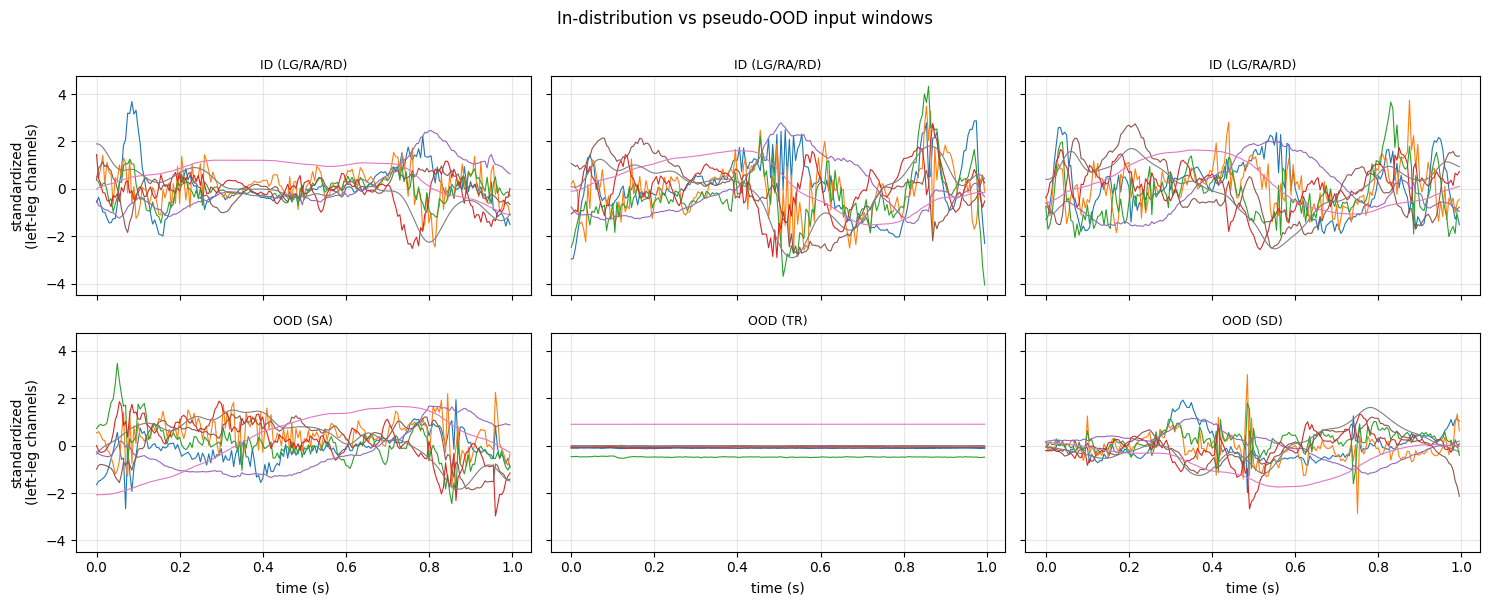

In [10]:
X = np.load(paths["AE_GAN"]["train"]["X"], mmap_mode="r")
Xo = np.load(paths["ood"]["test"]["X"], mmap_mode="r")
meta_o = pd.read_parquet(paths["ood"]["test"]["meta"])
sc = scalers["AE_GAN"]
t = np.arange(WINDOW) / SAMPLE_RATE_HZ

rng = np.random.default_rng(1)
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True, sharey=True)
for col in range(3):
    i = rng.integers(len(X))
    axes[0, col].plot(t, apply_scaler(np.asarray(X[i])[None], sc)[0, :8].T, lw=0.8)
    axes[0, col].set_title("ID (LG/RA/RD)", fontsize=9)

    j = rng.integers(len(Xo))
    axes[1, col].plot(t, apply_scaler(np.asarray(Xo[j])[None], sc)[0, :8].T, lw=0.8)
    axes[1, col].set_title(f"OOD ({meta_o.iloc[j]['mode']})", fontsize=9)

for ax in axes.flat:
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("standardized\n(left-leg channels)")
axes[1, 0].set_ylabel("standardized\n(left-leg channels)")
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
fig.suptitle("In-distribution vs pseudo-OOD input windows", y=1.0)
fig.tight_layout()

## Loading these arrays for training

```python
import numpy as np, pandas as pd, json
from pathlib import Path

P = Path("data/processed")

# --- gait-phase ensemble (labelled) ---
sc   = np.load(P / "scaler.npz")
X    = np.load(P / "train_X.npy", mmap_mode="r")      # (N, 16, 200) float32, UNSCALED
y    = np.load(P / "train_y.npy", mmap_mode="r")      # (N, 2) float32, sin(phase) in [-1, 1]
mask = np.load(P / "train_mask.npy", mmap_mode="r")   # (N, 2) float32, 1 = real label
meta = pd.read_parquet(P / "train_meta.parquet")

# --- autoencoder / GAN (unsupervised) ---
sc_ae = np.load(P / "AE_GAN" / "scaler.npz")
X_ae  = np.load(P / "AE_GAN" / "train_X.npy", mmap_mode="r")   # X only -- no y, no mask

# --- OOD evaluation (shared) ---
X_ood = np.load(P / "ood" / "test_X.npy", mmap_mode="r")
m_ood = pd.read_parquet(P / "ood" / "test_meta.parquet")       # 'mode' = which OOD task

# standardize a batch at load time, with the matching scaler
batch = (X[idx] - sc["mean"][None, :, None]) / sc["std"][None, :, None]
```

### The mask applies to the labelled set only

`data/processed/` keeps windows where only one leg has ground truth, storing `y = 0` and
`mask = 0` for the missing leg. **That zero is a placeholder, not a label** — in the tanh range
it would read as mid-stride. Apply the mask in the loss:

```python
def masked_mse(pred, target, mask):
    return ((pred - target) ** 2 * mask).sum() / mask.sum().clamp(min=1)
```

`AE_GAN/` has no such problem: those models reconstruct or discriminate the input itself, so
there is nothing to mask and no `mask` array is written.

### Evaluation

Score ID windows (`AE_GAN/{val,test}_X.npy` or the ensemble equivalent) and OOD windows
(`ood/{val,test}_X.npy`) with the model's `Ψ(x)`, apply the causal median filter, threshold at
the 99.5th percentile of training scores, and compare against the known ID/OOD label of each
window. Group by `meta['mode']` for the per-task breakdown the paper reports.